In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.parse_results import get_results

# Define Some Constants

In [ ]:
datasets = ["dsads", "rwhar", "pamap2", "opportunity"]
architectures = ["attend", "tinyhar", "convlstm"]
methods = ["unconstrained-synchronous_multisensor",
            "conservative-asynchronous_multisensor_time_context",
           "opportunistic-asynchronous_single_sensor",
           "conservative-asynchronous_multisensor",
           "opportunistic-asynchronous_multisensor_time_context",
           "conservative-asynchronous_single_sensor",
           "opportunistic-asynchronous_multisensor",
           ]
base_path = "../saved_data_cached/results/"

result_types = ['F1-macro','Accuracy','Active Error','Passive Error']
method_names = ["Battery-powered HAR",
                "Cons. Policy + MSC-T (BHAR)",
                "Opp. Policy + Single Sensor Classifier",
                "conservative\nasynchronous\nmultisensor",
                "opportunistic\nasynchronous\nmultisensor\ntime_context",
                "conservative\nasynchronous\nsingle_sensor",
                "opportunistic\nasynchronous\nmultisensor"
                ]

In [ ]:
plt.rcParams.update({
    # 1. Use STIX fonts - these are built-in to Matplotlib
    # and match the 'Times New Roman' / LaTeX serif aesthetic
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    
    # 2. Force the font to be consistent across text and math
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",
    
    # 3. Size adjustments for professional legibility
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.titlesize": 12,

    "axes.titleweight": "bold",    # Bold Subplot Titles
    "axes.labelweight": "bold",    # Bold X and Y Labels (e.g., "Performance")
    "font.weight": "bold",
})

In [ ]:
from matplotlib.ticker import AutoMinorLocator

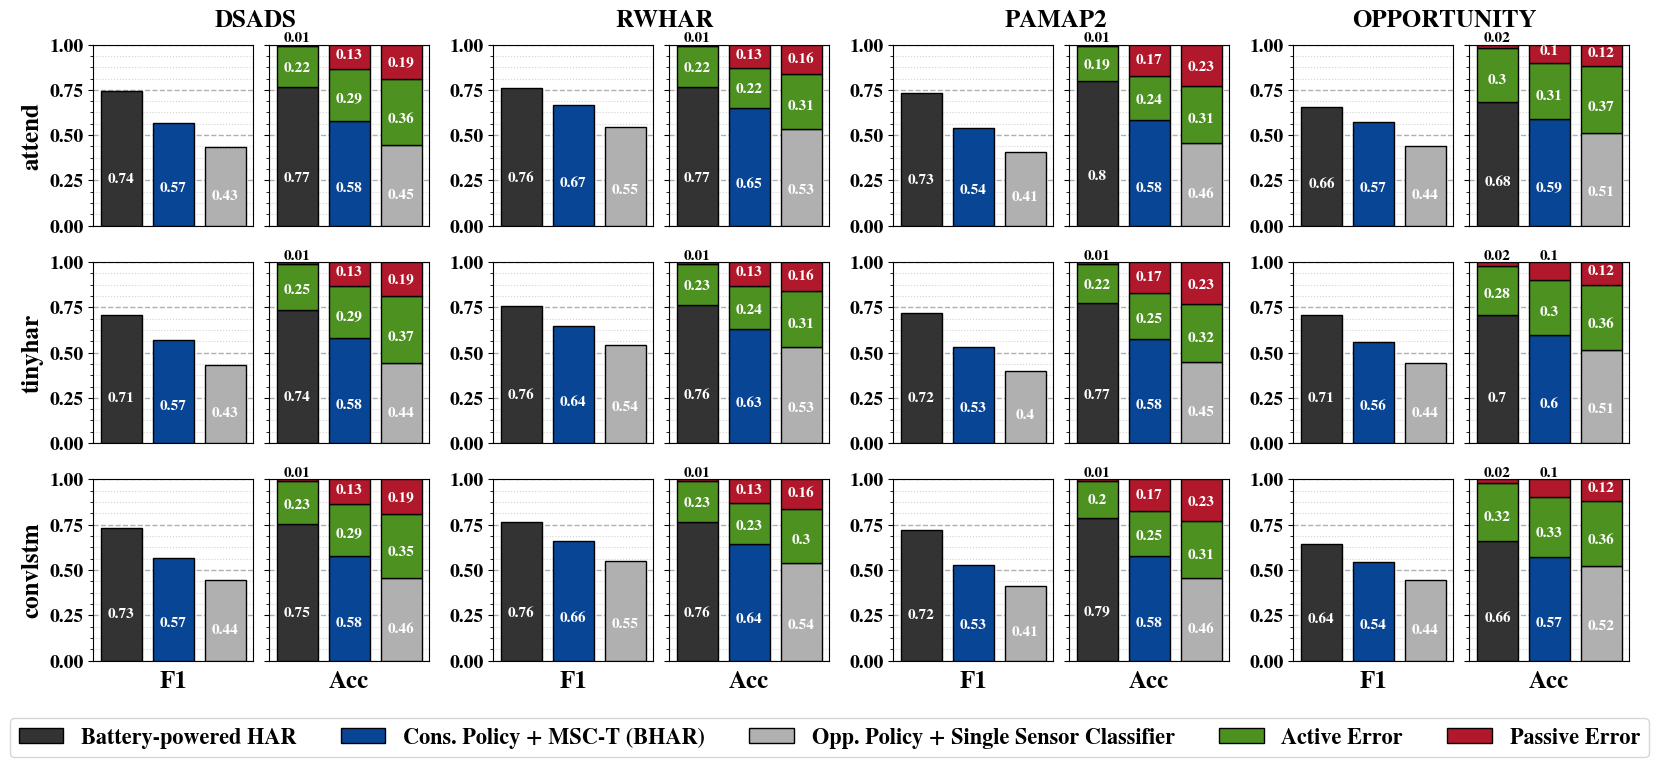

In [ ]:
cols = 2*len(datasets)
rows = len(architectures)
inc = 1/len(datasets)
space = 0.02
col_w = inc-2*space


fig = plt.figure(figsize=(16,8))
x_labels = [method_names[i] for i in range(3)]  # Categories
colors = ['#333333','#084594','#b0b0b0']

subplot_dict = {}
for d_i,dataset in enumerate(datasets):
    subplot_dict[dataset] = fig.subplots(rows,2, gridspec_kw=dict(left=d_i*inc+space, right=(d_i+1)*inc-space, wspace=0.1))

    for row in range(rows):
        for col in range(2):
            for x_i,x_label in enumerate(x_labels):
                result_path = os.path.join(base_path,dataset,architectures[row],methods[x_i])
                result_logs = [os.path.join(result_path, filename) for filename in os.listdir(result_path)]
                mean, std, _ = get_results(result_logs)
                f1_mean, acc_mean, active_err_mean, passive_err_mean = mean
                if col == 0:
                    subplot_dict[dataset][row][col].bar(x_label,f1_mean,zorder=3,label=x_label,color=colors[x_i],edgecolor="black",linewidth=1)
                    subplot_dict[dataset][row][col].text(x_label, 0.3*f1_mean, str(round(f1_mean,2)), ha='center', va='bottom',rotation=0,fontsize=11,c='white',fontweight='bold')
                if col == 1:
                    subplot_dict[dataset][row][col].bar(x_label,acc_mean,zorder=3,label=x_label,color=colors[x_i],edgecolor="black",linewidth=1)
                    subplot_dict[dataset][row][col].text(x_label, 0.3*acc_mean, str(round(acc_mean,2)), ha='center', va='bottom',rotation=0,fontsize=11,c='white',fontweight='bold')
                    
                    subplot_dict[dataset][row][col].bar(x_label,active_err_mean,bottom=acc_mean,zorder=3,color='#4d9221',edgecolor="black",linewidth=1,label='Active Error')
                    subplot_dict[dataset][row][col].text(x_label, acc_mean+0.3*active_err_mean, str(round(active_err_mean,2)), ha='center', va='bottom',rotation=0,fontsize=11,c='white',fontweight='bold')
                    
                    subplot_dict[dataset][row][col].bar(x_label,passive_err_mean,bottom=acc_mean+active_err_mean,zorder=3,color='#b2182b',edgecolor="black",linewidth=1,label='Passive Error')
                    if passive_err_mean < 0.1:
                        subplot_dict[dataset][row][col].text(x_label, 1, str(round(passive_err_mean,2)), ha='center', va='bottom',rotation=0,fontsize=11,c='k',fontweight='bold')
                    else:
                        subplot_dict[dataset][row][col].text(x_label, acc_mean+active_err_mean+0.3*passive_err_mean, str(round(passive_err_mean,2)), ha='center', va='bottom',rotation=0,fontsize=11,c='white',fontweight='bold')
            if col == 1:
                subplot_dict[dataset][row][col].set_yticklabels([]) 
            if d_i == 0 and col == 0:
                subplot_dict[dataset][row][col].set_ylabel(architectures[row],fontsize=18, fontweight='bold')
            subplot_dict[dataset][row][col].set_xticks([])
            subplot_dict[dataset][row][col].grid(True, which='both', axis='y', linestyle='--', linewidth=1)
            subplot_dict[dataset][row][col].yaxis.set_minor_locator(AutoMinorLocator(n=4))
            subplot_dict[dataset][row][col].grid(which='minor', axis='y', linestyle=':', linewidth=0.8, color='#d3d3d3')
            subplot_dict[dataset][row][col].tick_params(axis='both', which='major', labelsize=14)

            subplot_dict[dataset][row][col].set_ylim([0,1])

            if row == rows-1:
                if col == 0:
                    subplot_dict[dataset][row][col].text(1,-0.15,f'F1', fontsize=18, fontweight='bold',horizontalalignment='center')
                else:
                    subplot_dict[dataset][row][col].text(1,-0.15,f'Acc', fontsize=18, fontweight='bold',horizontalalignment='center')
    subplot_dict[dataset][0][0].text((14-len(datasets[d_i]))/5,1.1,f'{datasets[d_i].upper()}', fontsize=18, fontweight='bold')

handles, labels = plt.gca().get_legend_handles_labels()

# Remove duplicates from the legend by creating a set of labels and filtering the handles
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)

labels_to_end = ["Active Error", "Passive Error"]
leg_labels = []
for l in labels_to_end:
    idx = unique_labels.index(l)
    lab = unique_labels.pop(idx)
    han = unique_handles.pop(idx)
    if l == labels_to_end[0]:
        unique_labels.insert(4,lab)
        unique_handles.insert(4,han)
    else:
        unique_labels.insert(4,lab)
        unique_handles.insert(4,han)

# Create the legend with unique handles and labels
plt.legend(unique_handles, unique_labels,loc='center', bbox_to_anchor=(-4, -0.425), ncol=5,prop={'size': 16, 'weight': 'bold'})

# subplot_dict[dataset][-1][1].legend(loc='center', bbox_to_anchor=(-2.75, -0.45), ncol=2,prop={'size': 14, 'weight': 'bold'})
# plt.show()
plt.savefig('results.pdf',bbox_inches='tight')